<a href="https://colab.research.google.com/github/Dr-Isam-ALJAWARNEH/fds-project-geodevelopers/blob/main/Minimum_Spanning_Tree_for_Optimizing_Pollution_Monitoring_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Minimum Spanning Tree (MST) for Optimizing Pollution Monitoring Networks**

## **Importing the Required Libraries**

In [ ]:
# Installs the 'pygeohash' library, which provides functions to encode/decode geohashes
# Useful for spatial indexing and location-based clustering in geospatial datasets
%pip install pygeohash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00


In [ ]:
# Importing essential data processing and geospatial libraries
import pandas as pd         # For handling and analyzing structured tabular data (DataFrames)
import geopandas as gpd     # Extends pandas with geospatial operations on geometric types
import pygeohash as gh      # For encoding and decoding geographic coordinates into geohashes
import numpy as np          # For numerical operations, array handling, and mathematical functions

In [ ]:
from datascience import *
# Makes sure that any charts or plots show up directly below the code in a Jupyter notebook.
%matplotlib inline
#path_data = '../../../assets/data/'
# This is the main library used for creating plots and charts in Python.
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from matplotlib import colors # Brings in some extra tools to help with customizing plot colors.

In [ ]:
# Imports KMeans, a popular clustering algorithm used to group data into a fixed number of clusters.
from sklearn.cluster import KMeans

# Imports DBSCAN, another clustering algorithm that groups points based on density — good for finding irregular-shaped clusters.
from sklearn.cluster import DBSCAN

# Imports a method to calculate the great-circle distance — the shortest distance between two points on a sphere (like the Earth).
from geopy.distance import great_circle

# Imports a tool to scale or normalize data — helpful for making sure all features have equal weight during clustering.
from sklearn.preprocessing import StandardScaler


In [ ]:
# Imports Python's time module so we can measure how long different parts of the code take to run.
import time

# Lets us compute a matrix of distances between all pairs of points — useful for clustering or building graphs.
from scipy.spatial import distance_matrix

# Imports a built-in function to compute the Minimum Spanning Tree (MST) from a distance matrix.
from scipy.sparse.csgraph import minimum_spanning_tree

# These two functions help compute pairwise distances between points and convert them into a square matrix format.
from scipy.spatial.distance import pdist, squareform

# These to draw the map of Chicago
from shapely.geometry import Polygon

## **Configuring Variables & Importing Files**

In [ ]:
# Sets the precision level for geohashing — higher values mean smaller grid sizes (more detailed).
Geohash_percision = 6

In [ ]:
# Specifies the column name that holds the pollution values we want to analyze.
Analyzing_Pollution_Column = "TotalNormalizedPollution"

In [ ]:
# Creates an empty DataFrame using the datascience Table (to keep structure consistent at the start).
Chicago_df_original = Table().to_df()

# This loop loads 19 CSV files (parts of Chicago pollution data) from GitHub,
# and combines them into one large DataFrame.
for i in range(1,20):
  file_link = 'https://raw.githubusercontent.com/IsamAljawarneh/datasets/refs/heads/master/data/Chicago/AQ_data/chicago_eclipse_data_part_'+str(i)+'.csv'
  Chicago_df_original = pd.concat([Chicago_df_original, pd.read_csv(file_link,index_col=False)], ignore_index=True)

Chicago_df_original

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0


## **Analyzing, Cleaning & Organizing the Data**

In [ ]:
Chicago_df_all = Chicago_df_original
# Converts the 'ReadingDateTimeUTC' column into actual datetime objects and stores it in a new column called 'ReadingDate'.
# This makes it easier to filter or group data by date later.
Chicago_df_all['ReadingDate'] = pd.to_datetime(Chicago_df_all['ReadingDateTimeUTC'])
Chicago_df_all

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,ReadingDate
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:03:00,5.561094,NaN,NaN,NaN,0.123580,27.383499,55.128479,4.237187,93.964844,-76.0,2021-06-20 00:03:00
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:08:10,6.633914,NaN,NaN,NaN,0.132103,27.079086,55.059814,4.236094,93.964844,-81.0,2021-06-20 00:08:10
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:13:20,4.068707,NaN,NaN,NaN,0.131126,27.079086,55.035400,4.236406,93.964844,-80.0,2021-06-20 00:13:20
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:18:30,6.351702,NaN,NaN,NaN,0.138784,26.945572,54.632568,4.236094,93.863281,-82.0,2021-06-20 00:18:30
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-20 00:23:40,9.574065,NaN,NaN,NaN,0.413070,26.828079,53.907776,4.235938,93.863281,-81.0,2021-06-20 00:23:40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461084,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,4.479115,10.72,34.66,12.51,0.413648,22.817307,73.245239,4.176250,89.785156,-62.0,2021-10-03 23:29:48
2461085,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,6.322502,14.89,34.71,6.35,0.656208,22.713165,73.222351,4.186875,89.785156,-61.0,2021-10-03 23:34:58
2461086,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,9.796841,13.51,36.71,2.62,0.336273,22.659760,73.472595,4.186250,89.683594,-60.0,2021-10-03 23:40:08
2461087,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,5.173977,11.20,34.33,3.53,0.372924,22.526245,73.468018,4.186250,89.683594,-61.0,2021-10-03 23:45:17


In [ ]:
# Converts the pandas DataFrame back into a datascience Table format.
# This is useful to use datascience-specific functions for analysis or visualization.
Chicago_ds_all = Table().from_df(Chicago_df_all)
Chicago_ds_all

City,DeviceId,LocationName,Latitude,Longitude,ReadingDateTimeUTC,PM25,CalibratedPM25,CalibratedO3,CalibratedNO2,CO,Temperature,Humidity,BatteryLevel,PercentBattery,CellSignal,ReadingDate
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:03:00,5.56109,nan,nan,nan,0.12358,27.3835,55.1285,4.23719,93.9648,-76,2021-06-20 00:03:00
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:08:10,6.63391,nan,nan,nan,0.132103,27.0791,55.0598,4.23609,93.9648,-81,2021-06-20 00:08:10
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:13:20,4.06871,nan,nan,nan,0.131126,27.0791,55.0354,4.23641,93.9648,-80,2021-06-20 00:13:20
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:18:30,6.3517,nan,nan,nan,0.138784,26.9456,54.6326,4.23609,93.8633,-82,2021-06-20 00:18:30
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:23:40,9.57407,nan,nan,nan,0.41307,26.8281,53.9078,4.23594,93.8633,-81,2021-06-20 00:23:40
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:28:50,6.02794,nan,nan,nan,0.157761,26.7667,58.0338,4.23609,93.8633,-82,2021-06-20 00:28:50
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:34:00,3.61224,nan,nan,nan,0.115831,26.3367,56.1356,4.23625,93.8633,-81,2021-06-20 00:34:00
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:39:10,3.75591,nan,nan,nan,0.122269,26.2032,55.838,4.22625,93.8633,-81,2021-06-20 00:39:10
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:44:20,6.00689,nan,nan,nan,0.184926,26.1712,55.6427,4.23547,93.8633,-80,2021-06-20 00:44:20
Chicago,2002,State & Garfield (SB),41.7949,-87.6259,2021-06-20 00:49:30,8.50949,nan,nan,nan,0.11234,26.2032,55.4581,4.23609,93.8633,-80,2021-06-20 00:49:30


Text(0.5, 1.0, 'Pollution Levels vs ReadingDate')

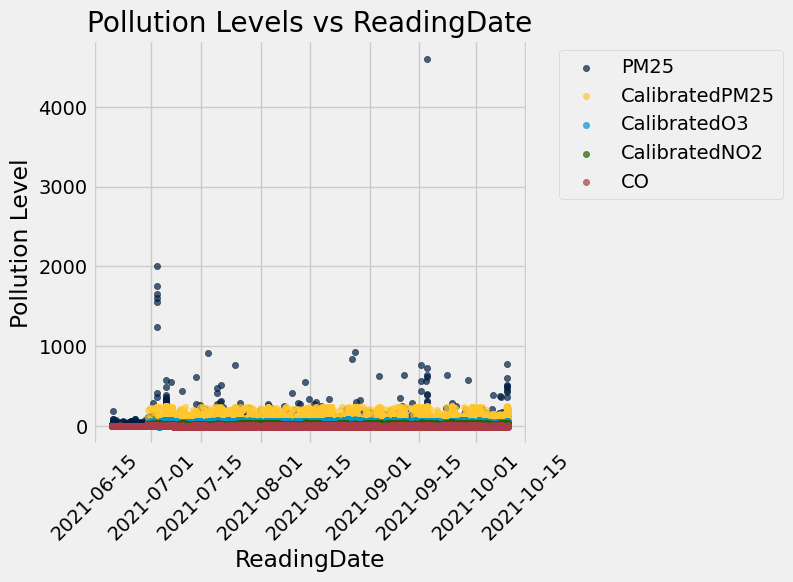

In [ ]:
# This plots shows how different pollution metrics (PM2.5, O3, NO2, CO) changed over time.
Chicago_ds_all.select("ReadingDate", "PM25", "CalibratedPM25", "CalibratedO3", "CalibratedNO2", "CO").scatter('ReadingDate')# Scatter plot with ReadingDate on x-axis
plt.xticks(rotation=45)# Rotate date labels for readability
plt.ylabel('Pollution Level')# Rotate date labels for readability
plt.title('Pollution Levels vs ReadingDate')# Chart title

In [ ]:
#The time-series analysis shows that PM2.5 readings contain noticeable outliers, which could distort the results. To ensure more accurate and reliable insights, it's better to use the calibrated pollution columns like CalibratedPM25, as they provide cleaner and more consistent measurements.

Text(0.5, 1.0, 'Calibrated Pollution Levels vs ReadingDate')

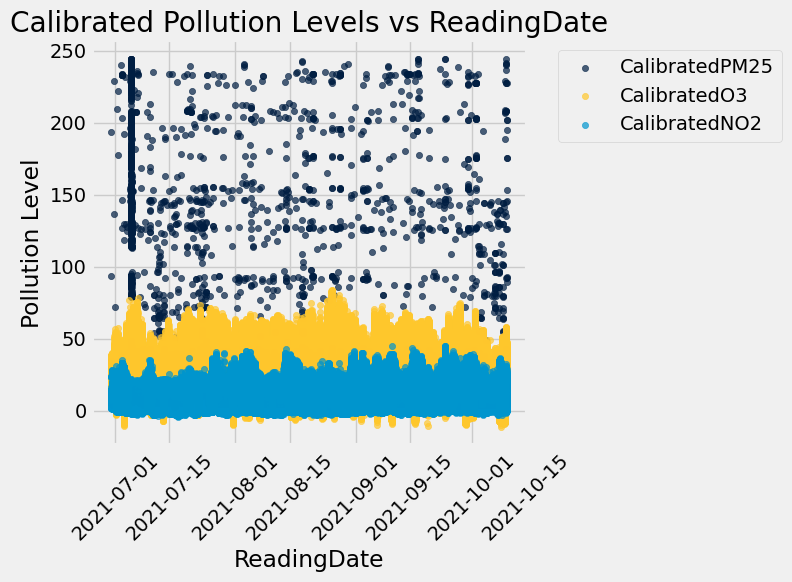

In [ ]:
# This plot focuses only on calibrated pollution data to avoid the influence of outliers in raw measurements.
Chicago_ds_all.select("ReadingDate", "CalibratedPM25", "CalibratedO3", "CalibratedNO2").scatter('ReadingDate') # Plot calibrated pollution levels over time
plt.xticks(rotation=45)# Rotate x-axis labels for better readability
plt.ylabel('Pollution Level')# Y-axis label
plt.title('Calibrated Pollution Levels vs ReadingDate')# Chart title

In [ ]:
#This graph displays calibrated pollution levels over time for PM2.5, O3, and NO2. The values are more consistent and reliable than raw data, with fewer outliers. All three columns will be normalized and summed later to create a single pollution score for analysis.

In [ ]:
# This function checks for missing values in each column of a datascience Table.
# It handles both numeric and string columns and prints the count of missing entries.

def check_missing_values(ds_table):
  for label in ds_table.labels:# Loop through all column names
      column = ds_table.column(label)# Get the data in the current column

      if np.issubdtype(type(column[0]), np.number):  # check numeric columns
          missing = np.count_nonzero(np.isnan(column)) # Count NaNs
      else:
          missing = np.count_nonzero(column == '') # Count empty strings

      print(f"Missing values in '{label}': {missing}")# Print missing count
  print("num rows: ", ds_table.num_rows)# Print total number of rows

In [ ]:
# Calls the function to check for missing values in the entire Chicago pollution dataset (in datascience Table format).

check_missing_values(Chicago_ds_all)

Missing values in 'City': 0
Missing values in 'DeviceId': 0
Missing values in 'LocationName': 0
Missing values in 'Latitude': 0
Missing values in 'Longitude': 0
Missing values in 'ReadingDateTimeUTC': 0
Missing values in 'PM25': 0
Missing values in 'CalibratedPM25': 34277
Missing values in 'CalibratedO3': 34277
Missing values in 'CalibratedNO2': 34277
Missing values in 'CO': 127
Missing values in 'Temperature': 0
Missing values in 'Humidity': 0
Missing values in 'BatteryLevel': 0
Missing values in 'PercentBattery': 0
Missing values in 'CellSignal': 0
Missing values in 'ReadingDate': 0
num rows:  2461089


In [ ]:
#The missing values are found in the calibrated pollution columns, which are the primary focus of our analysis. Therefore, it's best to drop rows with missing data in these columns. Missing values in the CO column can be safely ignored, as it is not critical to our main calculations.

In [ ]:
# Filters out rows where 'CalibratedPM25' is missing (NaN), since it's essential for the analysis.
Chicago_ds_cleaned = Chicago_ds_all.where(~np.isnan(Chicago_ds_all.column("CalibratedPM25")))
# Checks the cleaned dataset again to confirm missing values are handled.
check_missing_values(Chicago_ds_cleaned)

Missing values in 'City': 0
Missing values in 'DeviceId': 0
Missing values in 'LocationName': 0
Missing values in 'Latitude': 0
Missing values in 'Longitude': 0
Missing values in 'ReadingDateTimeUTC': 0
Missing values in 'PM25': 0
Missing values in 'CalibratedPM25': 0
Missing values in 'CalibratedO3': 0
Missing values in 'CalibratedNO2': 0
Missing values in 'CO': 127
Missing values in 'Temperature': 0
Missing values in 'Humidity': 0
Missing values in 'BatteryLevel': 0
Missing values in 'PercentBattery': 0
Missing values in 'CellSignal': 0
Missing values in 'ReadingDate': 0
num rows:  2426812


In [ ]:
#After removing the missing values from CalibratedPM25, the rest were removed also.

In [ ]:
Chicago_df_cleaned = Chicago_ds_cleaned.to_df()

In [ ]:
def plot_pollution_vs(df_table, AnalyzingColumn):
  fig, axes = plt.subplots(1, 3, figsize=(18,5))
  df_table.plot.scatter(x = AnalyzingColumn, y = "CalibratedPM25", ax=axes[0], color="#001E42", title="CalibratedPM25 vs " + AnalyzingColumn)
  df_table.plot.scatter(x = AnalyzingColumn, y = "CalibratedO3", ax=axes[1], color="#FEC72C", title="CalibratedO3 vs " + AnalyzingColumn)
  df_table.plot.scatter(x = AnalyzingColumn, y = "CalibratedNO2", ax=axes[2], color="#0095CD", title="CalibratedNO2 vs " + AnalyzingColumn)

  for ax in axes:
    for label in ax.get_xticklabels():
      label.set_rotation(45)

In [ ]:
#After removing rows with missing values in CalibratedPM25, the remaining calibrated pollution columns no longer contain missing values, as those rows were excluded together.

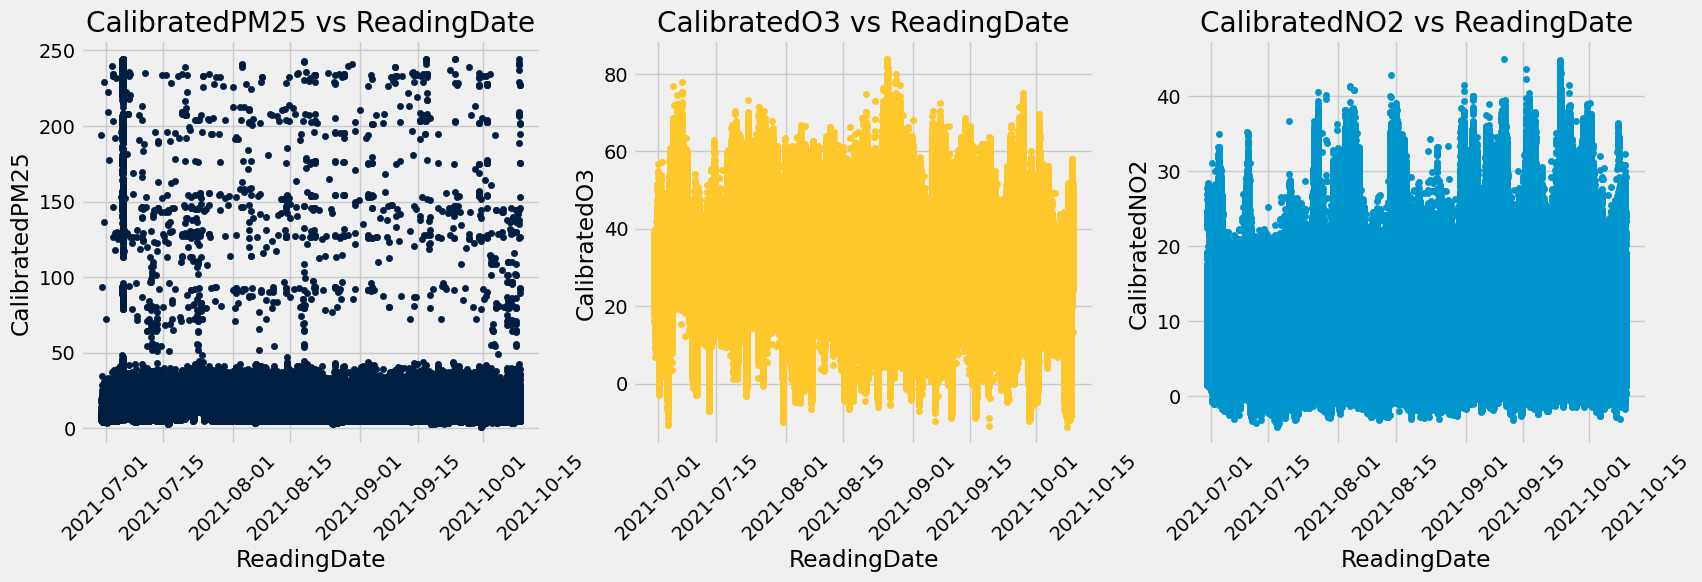

In [ ]:
## Plots pollution levels over time using the cleaned DataFrame and the specified date column.
plot_pollution_vs(Chicago_df_cleaned, "ReadingDate")

In [ ]:
# 1) PM2.5 values are much cleaner after removing missing entries, but still show some variation. No strong trend over time is visible.
# 2) Ozone levels (O3) fluctuate slightly but remain mostly stable throughout the observed period. No clear increase or decrease is seen.
# 3) NO2 levels are fairly consistent and stay within a narrow range. Time doesn’t appear to have a strong effect on its variation.

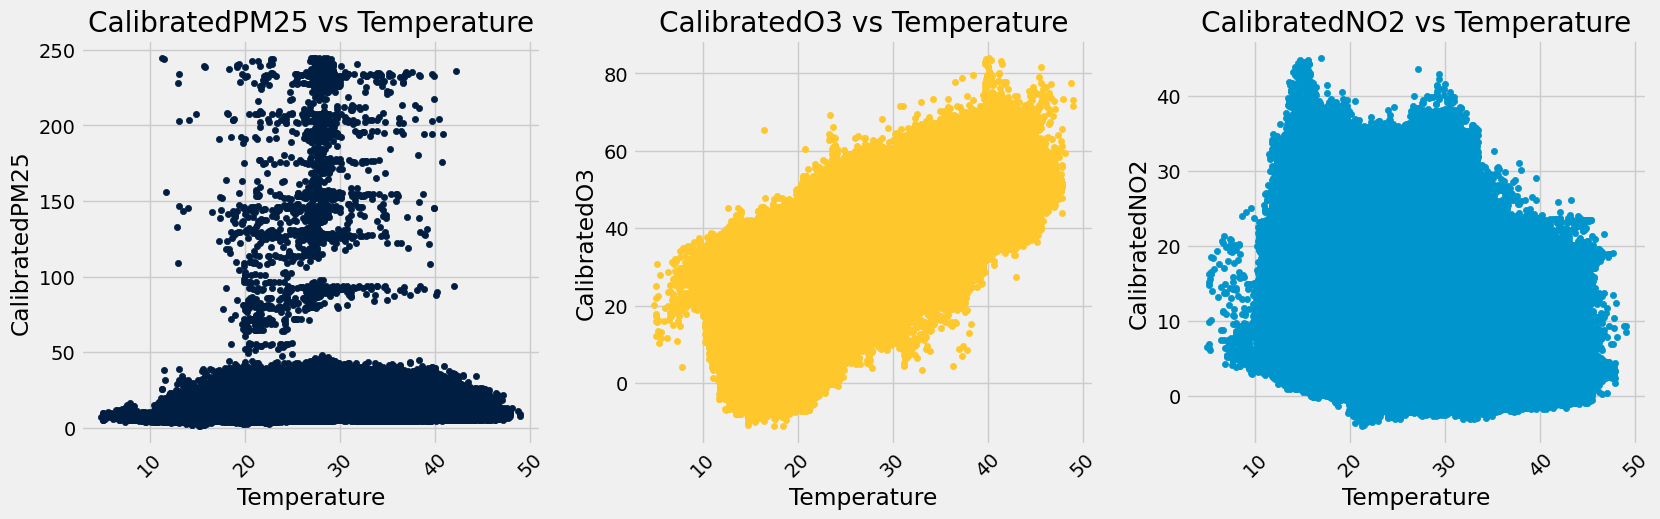

In [ ]:
# Plots the relationship between pollution levels and temperature using the cleaned dataset.
plot_pollution_vs(Chicago_df_cleaned, "Temperature")

In [ ]:
# 1) There is no strong visible relationship between PM2.5 and temperature. The values are spread across the temperature range, suggesting PM2.5 is not directly influenced by temperature.
# 2) Ozone (O3) levels show a clear positive correlation with temperature—higher temperatures tend to have higher O3 values. This may be due to increased sunlight and atmospheric reactions in warmer conditions.
# 3) NO2 values are mostly clustered in the mid-temperature range. There's no strong linear trend, but slight variations suggest that extreme temperatures may reduce NO2 concentration.

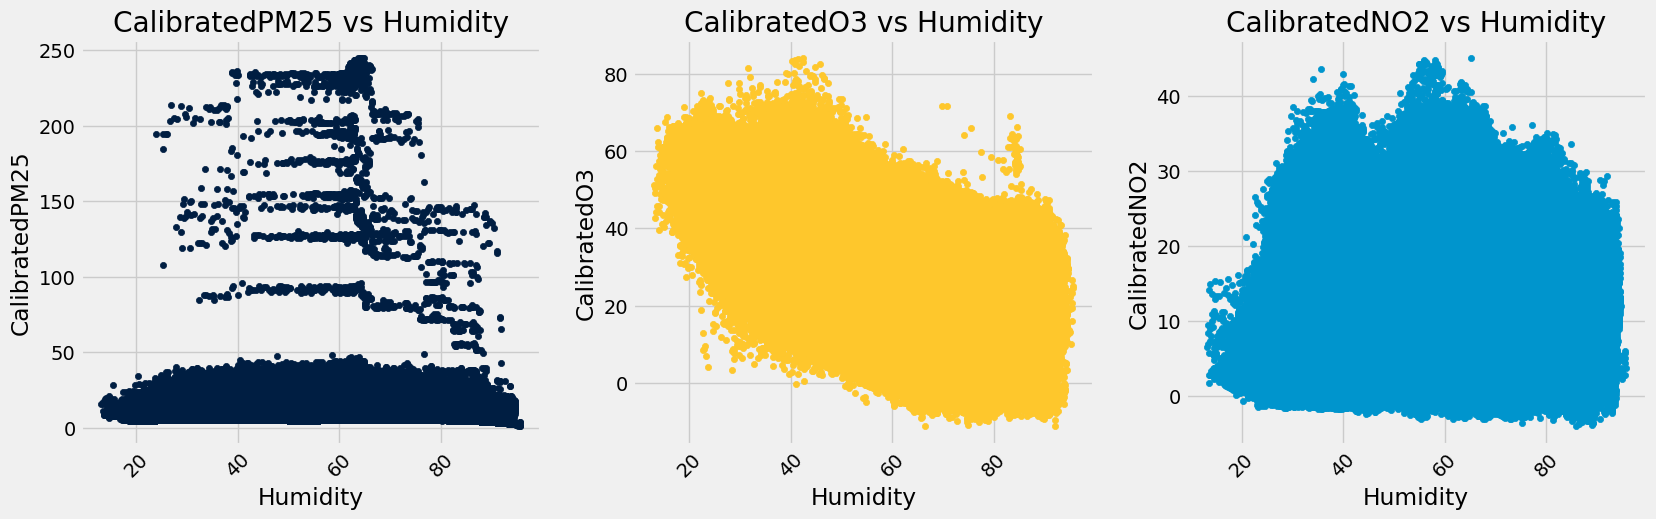

In [ ]:
# Plots how pollution levels vary with humidity using the cleaned dataset.
plot_pollution_vs(Chicago_df_cleaned, "Humidity")

In [ ]:
# 1) PM2.5 values are spread across all humidity levels with no clear pattern. Humidity does not show a strong influence on PM2.5 concentrations.
# 2) Ozone (O3) levels clearly decrease as humidity increases, showing a negative correlation. This is the opposite trend compared to temperature but still does not produce outliers.
# 3) NO2 values are fairly dense across mid-level humidity but show no strong upward or downward trend. The relationship with humidity appears weak or neutral

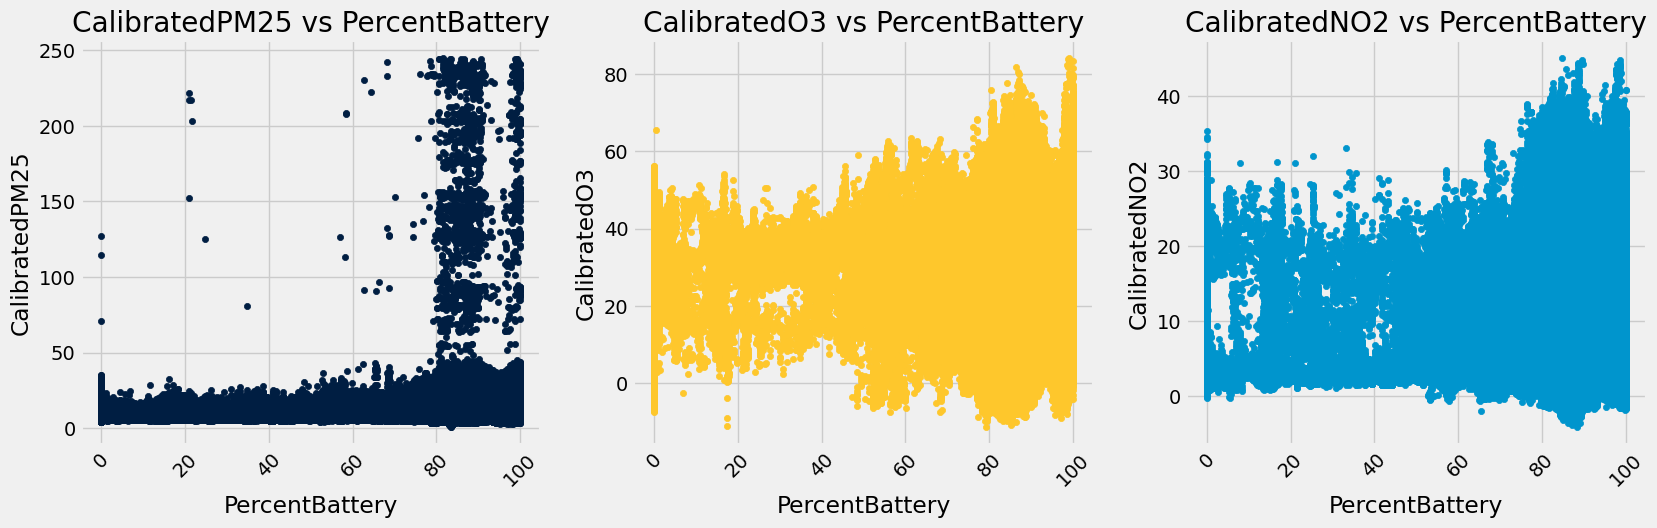

In [ ]:
# Plots how pollution levels relate to sensor battery percentage using the cleaned dataset.
plot_pollution_vs(Chicago_df_cleaned, "PercentBattery")

In [ ]:
# 1) PM2.5 values remain fairly consistent across battery levels. While very low battery levels show slightly more noise, the average stays aligned, indicating reliable calibration.
# 2) O3 levels show a slight increase as battery percentage rises, but the variation is minimal. Overall, battery level doesn’t introduce significant distortion or outliers.
# 3) NO2 readings are stable across all battery levels, with a slight dip when battery is low. This suggests sensors maintain accuracy even at reduced battery capacity.

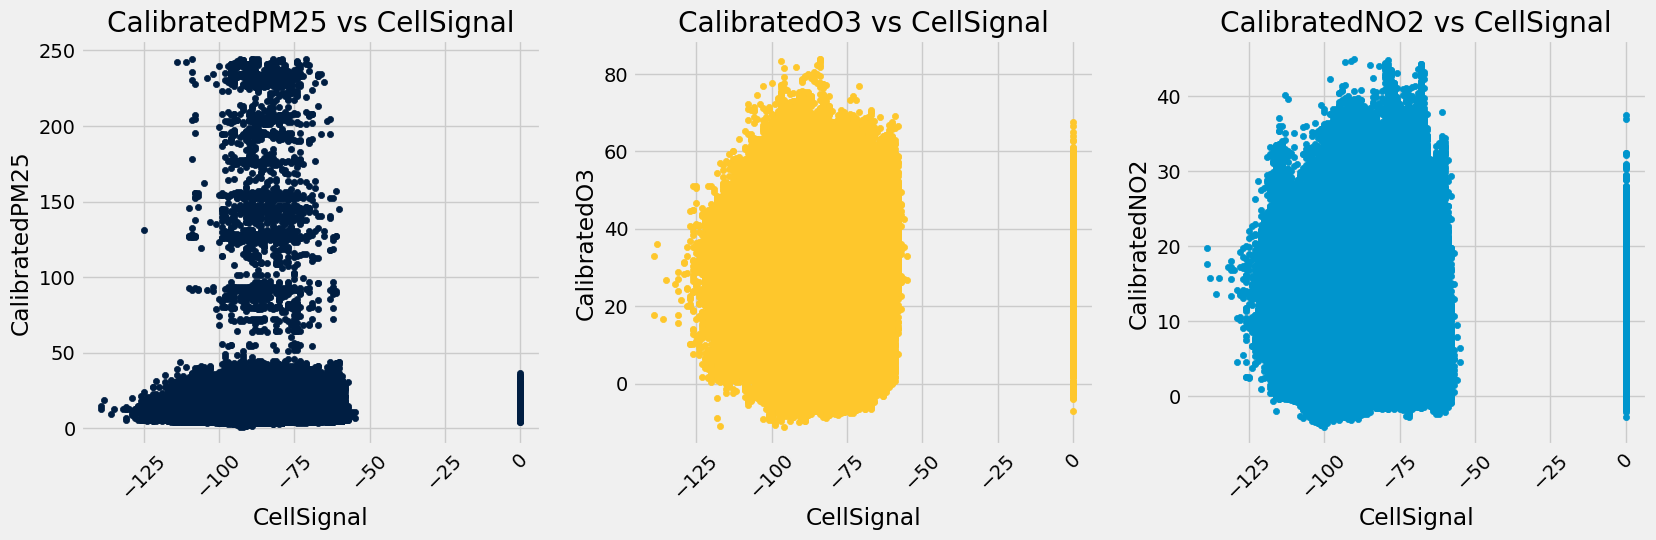

In [ ]:
# Plots how pollution levels vary with cell signal strength using the cleaned dataset.
plot_pollution_vs(Chicago_df_cleaned, "CellSignal")

In [ ]:
# 1) PM2.5 values remain stable across different cell signal strengths, indicating no dependency or distortion due to connectivity.
# 2) O3 levels are consistently distributed regardless of cell signal strength. Weak or strong signal does not affect the readings.
# 3) NO2 concentrations also show no noticeable pattern linked to signal strength. This confirms that signal quality does not impact pollution calibration.

Based on the analysis, the calibrated pollution levels remain consistent across all supporting variables, indicating that no additional filtering is necessary. Therefore, the related columns can be safely removed to reduce data volume and simplify the dataset.

In [ ]:
# Keeps only the essential columns related to location, device, date, and calibrated pollution values to reduce dataset size.
Chicago_df = Chicago_df_cleaned[["City",	"DeviceId",	"LocationName",	"Latitude",	"Longitude",	"ReadingDate", "CalibratedPM25",	"CalibratedO3",	"CalibratedNO2"]]
Chicago_df

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:01:33,7.01,25.86,2.83
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:06:43,7.35,25.62,3.29
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:11:53,9.26,26.26,3.51
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:17:03,8.46,25.32,7.05
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:22:13,9.91,24.79,6.69
...,...,...,...,...,...,...,...,...,...
2426807,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,10.72,34.66,12.51
2426808,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,14.89,34.71,6.35
2426809,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,13.51,36.71,2.62
2426810,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,11.20,34.33,3.53


In [ ]:
#Add Geohash grouping based on the latitude and longtiude columns
## This allows grouping nearby points into spatial grids based on the defined precision level.
Chicago_df["GeoHashCode"] = Chicago_df.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision= Geohash_percision), axis=1)
Chicago_df

<ipython-input-34-8f8b355de7a0>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df["GeoHashCode"] = Chicago_df.apply(lambda x: gh.encode(x.Latitude, x.Longitude, precision= Geohash_percision), axis=1)


,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2,GeoHashCode
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:01:33,7.01,25.86,2.83,dp3ty0
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:06:43,7.35,25.62,3.29,dp3ty0
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:11:53,9.26,26.26,3.51,dp3ty0
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:17:03,8.46,25.32,7.05,dp3ty0
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:22:13,9.91,24.79,6.69,dp3ty0
...,...,...,...,...,...,...,...,...,...,...
2426807,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,10.72,34.66,12.51,dp3wu7
2426808,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,14.89,34.71,6.35,dp3wu7
2426809,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,13.51,36.71,2.62,dp3wu7
2426810,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,11.20,34.33,3.53,dp3wu7


In [ ]:
# Min-Max Normalization: scales each pollution column to a 0–1 range for fair comparison.
pollution_columns = ['CalibratedPM25', 'CalibratedO3', 'CalibratedNO2']
for col in pollution_columns:
   Chicago_df.loc[:, f'Normalized{col}'] = (Chicago_df[col] - Chicago_df[col].min()) / (Chicago_df[col].max() - Chicago_df[col].min())
# Creates a single pollution index by summing the normalized values of PM2.5, O3, and NO2.
Chicago_df.loc[:, 'TotalNormalizedPollution'] = Chicago_df[[f'Normalized{col}' for col in pollution_columns]].sum(axis=1)
Chicago_df

<ipython-input-35-24cbac4a2386>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df.loc[:, f'Normalized{col}'] = (Chicago_df[col] - Chicago_df[col].min()) / (Chicago_df[col].max() - Chicago_df[col].min())
<ipython-input-35-24cbac4a2386>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df.loc[:, f'Normalized{col}'] = (Chicago_df[col] - Chicago_df[col].min()) / (Chicago_df[col].max() - Chicago_df[col].min())
<ipython-input-35-24cbac4a2386>:4: SettingWithCopyWarning: 
A value is trying to be se

,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2,GeoHashCode,NormalizedCalibratedPM25,NormalizedCalibratedO3,NormalizedCalibratedNO2,TotalNormalizedPollution
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:01:33,7.01,25.86,2.83,dp3ty0,0.024473,0.389152,0.140151,0.553776
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:06:43,7.35,25.62,3.29,dp3ty0,0.025870,0.386629,0.149521,0.562020
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:11:53,9.26,26.26,3.51,dp3ty0,0.033712,0.393356,0.154003,0.581072
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:17:03,8.46,25.32,7.05,dp3ty0,0.030427,0.383475,0.226115,0.640018
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-06-30 00:22:13,9.91,24.79,6.69,dp3ty0,0.036382,0.377904,0.218782,0.633067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2426807,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:29:48,10.72,34.66,12.51,dp3wu7,0.039708,0.481657,0.337340,0.858704
2426808,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:34:58,14.89,34.71,6.35,dp3wu7,0.056831,0.482182,0.211856,0.750869
2426809,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:40:08,13.51,36.71,2.62,dp3wu7,0.051164,0.503206,0.135873,0.690243
2426810,Chicago,2129,Lincoln & California (NWB),41.985920,-87.699628,2021-10-03 23:45:17,11.20,34.33,3.53,dp3wu7,0.041679,0.478188,0.154410,0.674277


## **Defining Functions & Implementing MST**

In [ ]:
# Groups the dataset by a given column (e.g., GeoHashCode or City) and calculates the average pollution values for each group.
# Also counts total records and unique sensors (DeviceId) in each group.
def group_and_average(df_table, group_column):
   result_rows = [] # Stores grouped summary rows
   unique_values = df_table[group_column].dropna().unique() # Get unique non-null group values
   for val in unique_values:
       group_df_table = df_table[df_table[group_column] == val] # Filter rows by current group value
       avg_values = group_df_table.mean(numeric_only=True)  # Compute average of numeric columns
       avg_values[group_column] = val # Add group value to the result
       avg_values['TotalRecords'] = len(group_df_table) # Total number of rows in this group
       avg_values['TotalSensors'] = group_df_table['DeviceId'].nunique() # Count of unique sensors
       result_rows.append(avg_values) # Add this group's summary to the result list
   result_df_table = pd.DataFrame(result_rows) # Convert list of rows to a DataFrame
   # Reorder columns: group key, counts first, then the rest
   cols = [group_column, 'TotalRecords', 'TotalSensors'] + [col for col in result_df_table.columns if col not in [group_column, 'TotalRecords', 'TotalSensors']]
   return result_df_table[cols] # Return the final grouped and ordered DataFrame

In [ ]:
# This function creates a stratified sample from the dataset, ensuring each group (e.g., sensor) is proportionally represented.

def stratified_sample(df_table, group_column='DeviceId', frac=0.2, random_state=None):
   """
   Returns a stratified sample of the input dataframe, preserving the proportion of each sensor's readings.
   Parameters:
       df_table (DataFrame): Input data with a column identifying sensor ID.
       sensor_column (str): Name of the column containing sensor IDs.
       frac (float): Fraction of rows to sample per group (default = 0.2 for 20%).
       random_state (int): Seed for reproducibility (optional).
   Returns:
       DataFrame: Stratified sampled data.
   """
   sampled_df = (
       df_table
       .groupby(group_column, group_keys=False)
       .apply(lambda x: x.sample(frac=frac, replace=False, random_state=random_state))
       .reset_index(drop=True)
   )
   return sampled_df

In [ ]:
# This function clusters nearby sensor points using their latitude, longitude, and pollution levels.
# It applies DBSCAN to group dense regions, calculates average pollution per cluster,
# and visualizes both the sensor locations and cluster centroids on a color-coded map.

def cluster_nearby_points(df_table, pollution_column, ax=None):
   subset = df_table.dropna(subset=['Latitude', 'Longitude', pollution_column]).copy()
   # Step 2: Extract and scale features
   features = subset[['Latitude', 'Longitude', pollution_column]].values
   scaler = StandardScaler()
   scaled_features = scaler.fit_transform(features)
   # Step 3: Apply DBSCAN
   db = DBSCAN(eps=0.3, min_samples=1)
   subset['Cluster'] = db.fit_predict(scaled_features)
   # Step 4: Remove noise
   clustered = subset[subset['Cluster'] != -1]
   # Step 5: Compute centroids and average pollution
   centroids = (
       clustered
       .groupby('Cluster')[['Latitude', 'Longitude', pollution_column]]
       .mean()
       .reset_index()
       #.rename(columns={pollution_column: f'Avg_{pollution_column}'})
   )
   # Step 6: Plot
   if ax is None:
       fig, ax = plt.subplots(figsize=(10, 8))
   ax.scatter(clustered['Longitude'], clustered['Latitude'], c='skyblue', s=50, alpha=0.6, label='Sensor Points')
   #ax.scatter(centroids['Longitude'], centroids['Latitude'], c='red', s=30, marker='X', label='Cluster Centroids')
   # Color-coded centroids
   pollution_levels = centroids[pollution_column]
   norm = colors.Normalize(pollution_levels.min(), pollution_levels.max())
   cmap = plt.get_cmap('YlOrRd')
    # Plot cluster centroids as 'X' markers, colored by average pollution level

   scatter = ax.scatter(
      centroids['Longitude'],
      centroids['Latitude'],
      c=pollution_levels,
      cmap=cmap,
      norm=norm,
      s=100,
      marker='X',
      edgecolor='black',
      label='Cluster Centroids'
  )
# Customize plot appearance
   ax.set_title("Nearby Clustered Sensor Points", fontsize=12)
   ax.set_xlabel("Longitude")
   ax.set_ylabel("Latitude")
   ax.legend()
   ax.grid(True)
   # attach colorbar to the scatter plot
   cbar = ax.figure.colorbar(scatter)
   cbar.set_label(f'Avg {pollution_column}')
   return clustered, centroids

In [ ]:
# This function builds a Minimum Spanning Tree (MST) over sensor locations,
# where edge weights are adjusted by both spatial distance and pollution levels.
# It returns the total weighted path length and visualizes the MST on a map.

def mst_with_pollution(df_table, pollution_column, ax=None):
   start_time = time.time()
   # Filter for valid rows (with pollution and location)
   df_subset = df_table.dropna(subset=['Latitude', 'Longitude', pollution_column]).copy()
   # Step 1: Normalize the pollution column (0–1)
   pollution_vals = df_subset[pollution_column].values
   pollution_norm = pollution_vals #(pollution_vals - pollution_vals.min()) / (pollution_vals.max() - pollution_vals.min())
   # Step 2: Compute the spatial distance matrix
   coords = df_subset[['Latitude', 'Longitude']].values
   spatial_dist = distance_matrix(coords, coords)
   # Step 3: Compute pollution influence (average pollution between point pairs)
   pollution_matrix = np.add.outer(pollution_norm, pollution_norm) / 2
   # Step 4: Combine into a weighted matrix: Distance × (1 + pollution influence)
   weighted_dist_matrix = spatial_dist * (1 + pollution_matrix)
   # Step 5: Compute MST
   mst = minimum_spanning_tree(weighted_dist_matrix).toarray()
   # Step 6: Compute total path length
   total_weight = mst[mst > 0].sum()
   elapsed_time = time.time() - start_time
   # Step 7: Plot
   if ax is None:
       fig, ax = plt.subplots(figsize=(10, 8))
   ax.scatter(df_subset['Longitude'], df_subset['Latitude'], s=8, color='blue', alpha=0.7)
# Draw lines between connected points in the MST

   for i in range(len(mst)):
       for j in range(len(mst)):
           if mst[i][j] > 0:
               plt.plot(
                   [df_subset.iloc[i]['Longitude'], df_subset.iloc[j]['Longitude']],
                   [df_subset.iloc[i]['Latitude'], df_subset.iloc[j]['Latitude']],
                   'k-', linewidth=0.5
               )
# Add plot title with total MST weight and time taken

   plt.title(f"MST Weighted by Distance and {pollution_column} | Total Weight: {total_weight:.2f} | Elapsed Time: {elapsed_time:.4f}s", fontsize=12)
   plt.xlabel("Longitude")
   plt.ylabel("Latitude")
   plt.grid(True)
   plt.tight_layout()
   plt.show()
   return total_weight, mst

In [ ]:
# This function visually compares clustering and MST analysis for a given pollution column.
# It can show clusters of nearby points and/or the minimum spanning tree (MST) based on spatial distance and pollution influence.

def plot_comparison(df_table, pollution_column, show_cluster=True, show_mst=True):
   import matplotlib.pyplot as plt
   plots = sum([show_cluster, show_mst]) # Count how many plots we need based on what the user wants to show
   fig, axes = plt.subplots(1, plots, figsize=(12 * plots, 8))     # Set up subplot layout (1 row, multiple columns depending on plots requested)

   if plots == 1:
       axes = [axes]  # ensure iterable
   idx = 0 # To track subplot index
 # If clustering is enabled, plot sensor clusters based on geohash and pollution

   if show_cluster:
       cluster_nearby_geohash_points(df_table, pollution_column, ax=axes[idx])
       idx += 1

# If MST is enabled, plot the minimum spanning tree weighted by pollution and distance
   if show_mst:
       mst_with_pollution(df_table, pollution_column, ax=axes[idx])
   plt.tight_layout()
   plt.show()

In [ ]:
# This function provides suggestions for adjusting sensor deployment based on normalized pollution levels,
# sensor density, and data availability. It helps optimize sensor placement across different areas.

def suggest_sensor_adjustment(df_table, pollution_column, sensor_count_col='TotalSensors', record_count_col='TotalRecords'):
   max_sensors = df_table[sensor_count_col].max()
   # Normalize pollution to 0–1 scale for consistent comparison
   pollution_values = df_table[pollution_column]
   pollution_min = pollution_values.min()
   pollution_max = pollution_values.max()
    # Handle edge case: if all pollution values are the same, assign a neutral level
   if pollution_max == pollution_min:
       df_table['PollutionLevel'] = 0.5  # assume moderate pollution
   else:
       df_table['PollutionLevel'] = (pollution_values - pollution_min) / (pollution_max - pollution_min)
   suggestions = [] # To store sensor adjustment suggestions

    # Loop through each row to analyze conditions and generate a recommendation

   for _, row in df_table.iterrows():
       level = row['PollutionLevel']
       sensors = row[sensor_count_col]
       records = row[record_count_col]

       if records < 100 and sensors < max_sensors:
           suggestion = "Collect more data before adjusting"
       elif level > 0.65 and sensors < max_sensors:
           suggestion = "Increase sensors (high normalized pollution)"
       elif level < 0.35 and sensors == max_sensors:
           suggestion = "Decrease sensors (low pollution, max sensors)"
       else:
           suggestion = "Maintain current sensor count"
       suggestions.append(suggestion)
   df_table['Suggestion'] = suggestions
   return df_table

In [ ]:
# Groups the dataset by each sensor (DeviceId), calculates average pollution values,
# and summarizes total readings and sensor-specific data.
Pollution_By_Sensor = group_and_average(Chicago_df, "DeviceId")
Pollution_By_Sensor

,DeviceId,TotalRecords,TotalSensors,Latitude,Longitude,CalibratedPM25,CalibratedO3,CalibratedNO2,NormalizedCalibratedPM25,NormalizedCalibratedO3,NormalizedCalibratedNO2,TotalNormalizedPollution
0,2002.0,28027.0,1.0,41.794921,-87.625857,12.734706,30.507605,10.319326,0.047981,0.438007,0.292714,0.778701
1,2003.0,28142.0,1.0,41.795500,-87.625500,11.718640,30.904625,8.139903,0.043808,0.442180,0.248317,0.734306
2,2004.0,28368.0,1.0,41.845100,-87.695204,13.048965,32.377175,9.906979,0.049271,0.457660,0.284314,0.791245
3,2005.0,28302.0,1.0,41.852400,-87.695200,13.608612,30.283518,9.652375,0.051569,0.435651,0.279128,0.766348
4,2006.0,28306.0,1.0,41.852300,-87.695400,13.601985,32.949301,10.974670,0.051542,0.463674,0.306064,0.821280
...,...,...,...,...,...,...,...,...,...,...,...,...
116,2037.0,9.0,1.0,41.823716,-87.646346,16.417778,33.063333,26.370000,0.063104,0.464873,0.619678,1.147655
117,2033.0,13.0,1.0,41.759507,-87.644385,13.286923,33.016923,19.513846,0.050248,0.464385,0.480013,0.994646
118,2040.0,5.0,1.0,41.881471,-87.672189,15.394000,28.116000,24.962000,0.058900,0.412867,0.590996,1.062763
119,2042.0,8.0,1.0,41.844200,-87.724800,14.596250,32.378750,19.647500,0.055625,0.457676,0.482736,0.996037


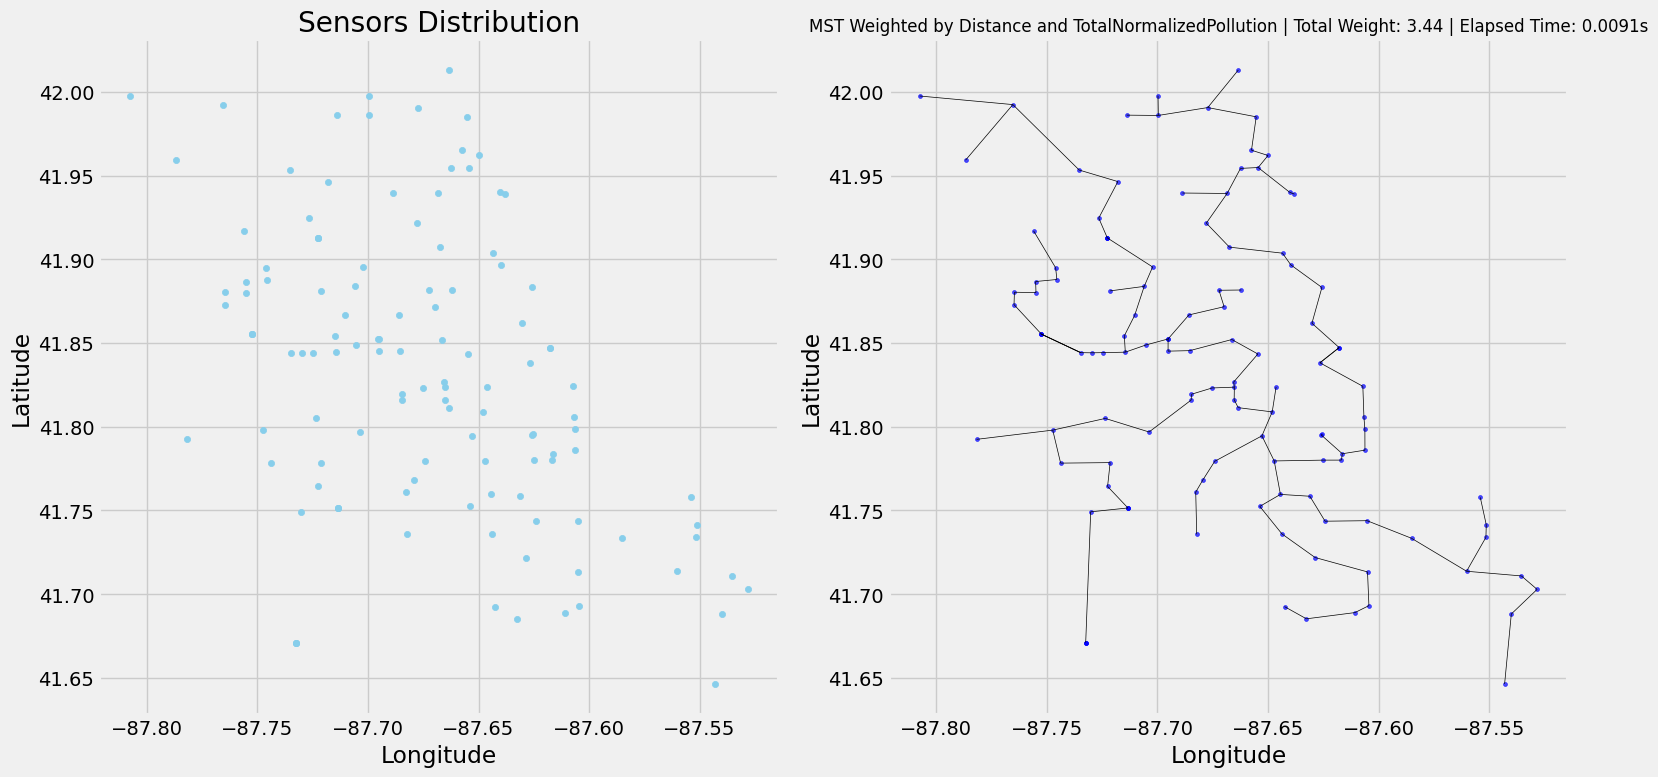

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8)) # Create a figure with 2 side-by-side subplots (1 row, 2 columns)
# Left plot: Show sensor locations on a scatter plot
Pollution_By_Sensor.plot.scatter(x = "Longitude", y = "Latitude", ax=ax[0], c='skyblue', title="Sensors Distribution")

# Right plot: Display the MST (Minimum Spanning Tree) based on distance and pollution
mst_with_pollution(Pollution_By_Sensor, Analyzing_Pollution_Column, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
'''
In above plots:

1) Left Plot – Sensors Distribution:

This shows the geographic spread of sensors across the Chicago area. The points are evenly distributed, covering both densely and sparsely monitored regions.

2) Right Plot – MST with Pollution Weighting:

This plot visualizes the Minimum Spanning Tree connecting all sensor points. The edges are influenced by both distance and pollution levels, forming an efficient network that prioritizes areas with higher pollution impact.

'''

'\nIn above plots:\n\n1) Left Plot – Sensors Distribution:\n\nThis shows the geographic spread of sensors across the Chicago area. The points are evenly distributed, covering both densely and sparsely monitored regions.\n\n2) Right Plot – MST with Pollution Weighting:\n\nThis plot visualizes the Minimum Spanning Tree connecting all sensor points. The edges are influenced by both distance and pollution levels, forming an efficient network that prioritizes areas with higher pollution impact.\n\n'

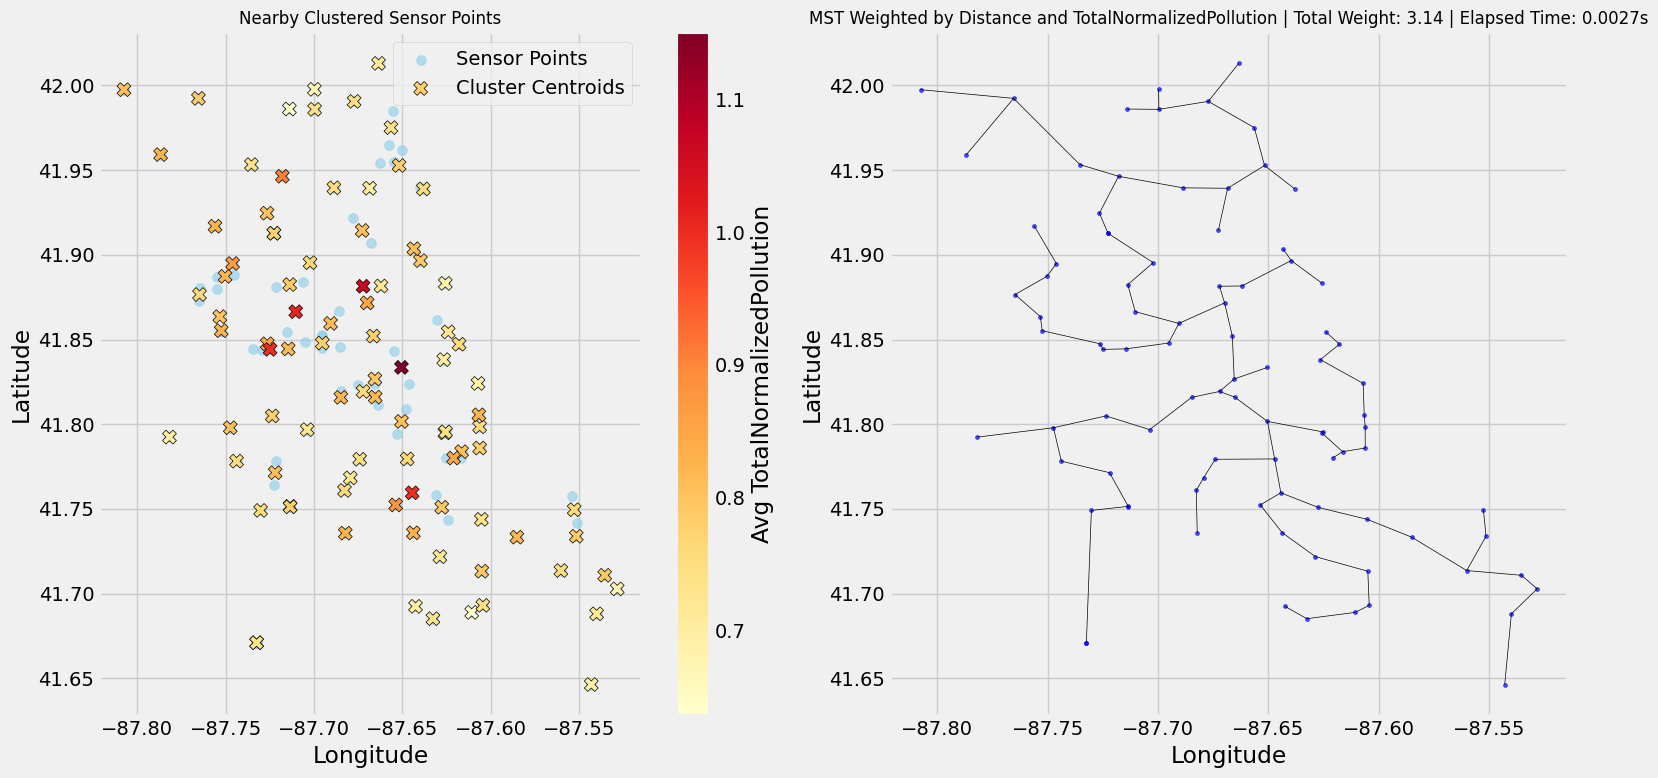

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create a side-by-side figure layout with 2 subpl
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Cluster nearby sensors and plot sensor points and pollution-colored centroids
clustered_sensors, centroids_sensors = cluster_nearby_points(Pollution_By_Sensor, Analyzing_Pollution_Column, ax=ax[0])

# Right plot: Build and display the MST using the centroids of the clusters
mst_with_pollution(centroids_sensors, Analyzing_Pollution_Column, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
'''

In above plots:
1) Left Plot – Nearby Clustered Sensor Points:

Sensors are grouped into clusters, with centroids color-coded by average pollution level. Darker red indicates higher pollution, helping identify hotspots for focused monitoring.

2) Right Plot – MST on Cluster Centroids:

A Minimum Spanning Tree connects cluster centroids efficiently, minimizing total travel or connection cost while factoring in both distance and pollution levels. It shows the optimal linking path for pollution-aware network design.

'''

'\n\nIn above plots:\n1) Left Plot – Nearby Clustered Sensor Points:\n\nSensors are grouped into clusters, with centroids color-coded by average pollution level. Darker red indicates higher pollution, helping identify hotspots for focused monitoring.\n\n2) Right Plot – MST on Cluster Centroids:\n\nA Minimum Spanning Tree connects cluster centroids efficiently, minimizing total travel or connection cost while factoring in both distance and pollution levels. It shows the optimal linking path for pollution-aware network design.\n\n'

In [ ]:
# Groups the dataset by geohash code, calculating average pollution values,
# and includes the total number of records and unique sensors in each spatial grid.

Pollution_By_Geohash = group_and_average(Chicago_df, "GeoHashCode")
Pollution_By_Geohash

,GeoHashCode,TotalRecords,TotalSensors,DeviceId,Latitude,Longitude,CalibratedPM25,CalibratedO3,CalibratedNO2,NormalizedCalibratedPM25,NormalizedCalibratedO3,NormalizedCalibratedNO2,TotalNormalizedPollution
0,dp3ty0,56169,2,2002.501024,41.795211,-87.625678,12.225633,30.706521,9.227383,0.045890,0.440098,0.270470,0.756458
1,dp3wh3,28368,1,2004.000000,41.845100,-87.695204,13.048965,32.377175,9.906979,0.049271,0.457660,0.284314,0.791245
2,dp3wh6,56608,2,2005.500035,41.852350,-87.695300,13.605298,31.616503,10.313569,0.051555,0.449664,0.292597,0.793816
3,dp3ts0,56511,3,2012.944506,41.751499,-87.713489,11.057970,33.037811,6.500428,0.041095,0.464604,0.214920,0.720620
4,dp3w7v,56735,3,2009.752587,41.912740,-87.722674,10.927356,34.219436,6.198642,0.040559,0.477026,0.208773,0.726357
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,dp3tvt,9,1,2037.000000,41.823716,-87.646346,16.417778,33.063333,26.370000,0.063104,0.464873,0.619678,1.147655
102,dp3ttd,13,1,2033.000000,41.759507,-87.644385,13.286923,33.016923,19.513846,0.050248,0.464385,0.480013,0.994646
103,dp3wkb,5,1,2040.000000,41.881471,-87.672189,15.394000,28.116000,24.962000,0.058900,0.412867,0.590996,1.062763
104,dp3w5c,8,1,2042.000000,41.844200,-87.724800,14.596250,32.378750,19.647500,0.055625,0.457676,0.482736,0.996037


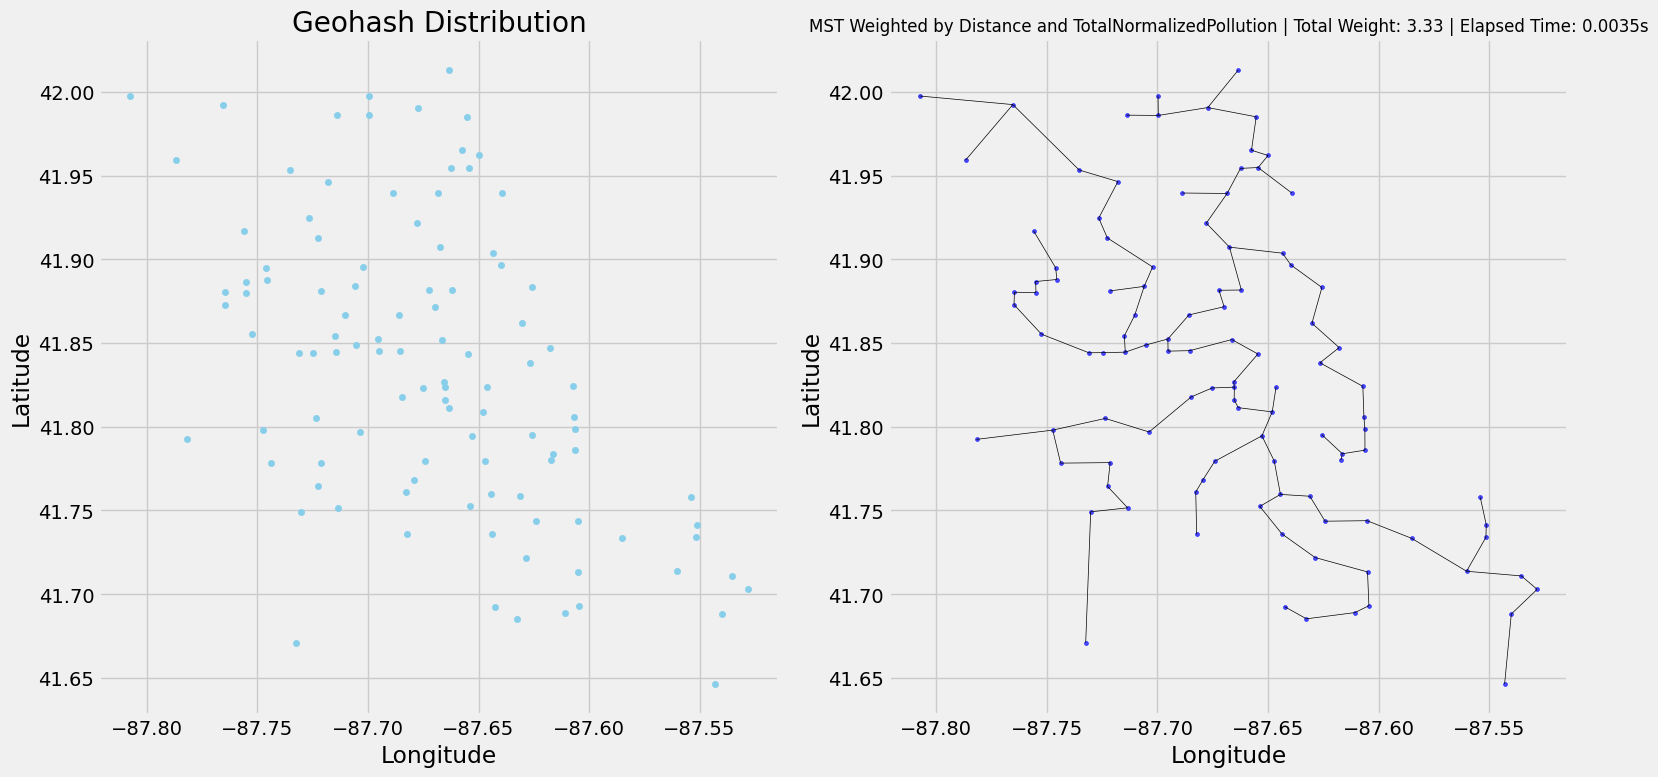

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create a figure with 2 subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Visualize the spatial distribution of geohash centroids
Pollution_By_Geohash.plot.scatter(x = "Longitude", y = "Latitude", ax=ax[0], c='skyblue', title="Geohash Distribution")

# Right plot: Generate the Minimum Spanning Tree based on pollution-weighted distances across geohash areas
mst_with_pollution(Pollution_By_Geohash, Analyzing_Pollution_Column, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
'''

In the above plots:

1) Left Plot – Geohash Distribution:

This shows the spatial centroids of geohash regions across Chicago. The points represent average locations of sensor readings grouped by geohash, providing a grid-based spatial overview.

2) Right Plot – MST Weighted by Pollution:

A Minimum Spanning Tree connects these geohash centroids using a pollution-weighted distance metric. It forms an efficient network path that prioritizes linking high-impact areas for optimized monitoring or routing.

'''

'\n\nIn the above plots:\n\n1) Left Plot – Geohash Distribution:\n\nThis shows the spatial centroids of geohash regions across Chicago. The points represent average locations of sensor readings grouped by geohash, providing a grid-based spatial overview.\n\n2) Right Plot – MST Weighted by Pollution:\n\nA Minimum Spanning Tree connects these geohash centroids using a pollution-weighted distance metric. It forms an efficient network path that prioritizes linking high-impact areas for optimized monitoring or routing.\n\n'

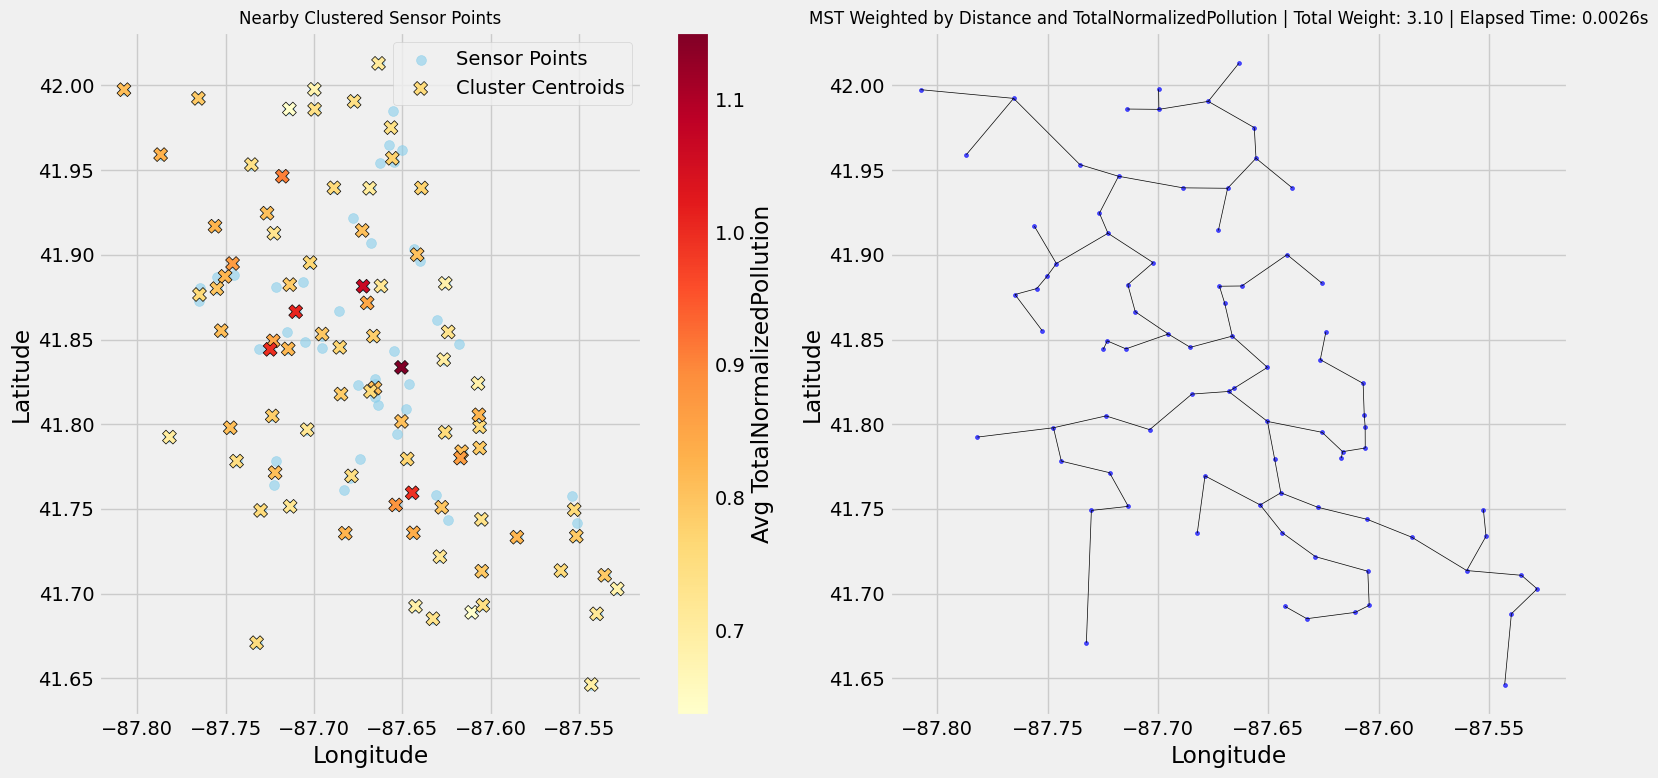

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create a figure with two side-by-side subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Cluster geohash centroids based on spatial proximity and pollution levels, then plot
clustered_geohash, centroids_geohash = cluster_nearby_points(Pollution_By_Geohash, Analyzing_Pollution_Column, ax=ax[0])

# Right plot: Draw MST using the clustered centroids to show efficient connections across grouped regions
mst_with_pollution(centroids_geohash, Analyzing_Pollution_Column, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
'''
In the above plots:

1) Left Plot – Nearby Clustered Sensor Points:
This visual groups geohash-level data points into clusters and shows centroids colored by average pollution. Darker red clusters indicate higher pollution, highlighting critical zones in need of monitoring or action.

2) Right Plot – MST on Cluster Centroids:
The Minimum Spanning Tree connects these clustered centroids using a pollution-weighted path, ensuring efficient network coverage while prioritizing areas with higher pollution intensity.

'''

'\nIn the above plots:\n\n1) Left Plot – Nearby Clustered Sensor Points:\nThis visual groups geohash-level data points into clusters and shows centroids colored by average pollution. Darker red clusters indicate higher pollution, highlighting critical zones in need of monitoring or action.\n\n2) Right Plot – MST on Cluster Centroids:\nThe Minimum Spanning Tree connects these clustered centroids using a pollution-weighted path, ensuring efficient network coverage while prioritizing areas with higher pollution intensity.\n\n'

In [ ]:
# Draws a stratified 10% sample from the full dataset, ensuring each sensor (DeviceId) is proportionally represented.
Sample_Data = stratified_sample(Chicago_df, "DeviceId", 0.1)
Sample_Data

<ipython-input-37-6150f02a64ba>:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=frac, replace=False, random_state=random_state))


,City,DeviceId,LocationName,Latitude,Longitude,ReadingDate,CalibratedPM25,CalibratedO3,CalibratedNO2,GeoHashCode,NormalizedCalibratedPM25,NormalizedCalibratedO3,NormalizedCalibratedNO2,TotalNormalizedPollution
0,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-09-04 12:01:39,8.05,31.58,16.20,dp3ty0,0.028744,0.449280,0.412508,0.890531
1,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-09-17 19:15:55,12.09,38.81,6.71,dp3ty0,0.045333,0.525281,0.219189,0.789804
2,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-09-06 12:51:28,11.99,20.85,30.90,dp3ty0,0.044923,0.336487,0.711958,1.093367
3,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-09-27 10:45:31,11.15,29.76,24.68,dp3ty0,0.041473,0.430148,0.585252,1.056873
4,Chicago,2002,State & Garfield (SB),41.794921,-87.625857,2021-07-18 16:47:02,15.47,45.29,7.55,dp3ty0,0.059212,0.593399,0.236301,0.888912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242674,Chicago,2214,EPA COM ED Maintenance Bldg F,41.751200,-87.713490,2021-08-21 02:36:10,6.23,28.43,15.90,dp3ts0,0.021270,0.416167,0.406396,0.843834
242675,Chicago,2214,EPA COM ED Maintenance Bldg F,41.751200,-87.713490,2021-08-22 11:40:05,12.84,25.50,16.37,dp3ts0,0.048413,0.385367,0.415971,0.849751
242676,Chicago,2214,EPA COM ED Maintenance Bldg F,41.751200,-87.713490,2021-08-22 17:04:07,17.78,8.80,17.84,dp3ts0,0.068698,0.209818,0.445916,0.724432
242677,Chicago,2214,EPA COM ED Maintenance Bldg F,41.751200,-87.713490,2021-08-22 04:55:06,14.37,17.57,17.55,dp3ts0,0.054696,0.302008,0.440008,0.796711


<ipython-input-39-eecae4451f67>:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


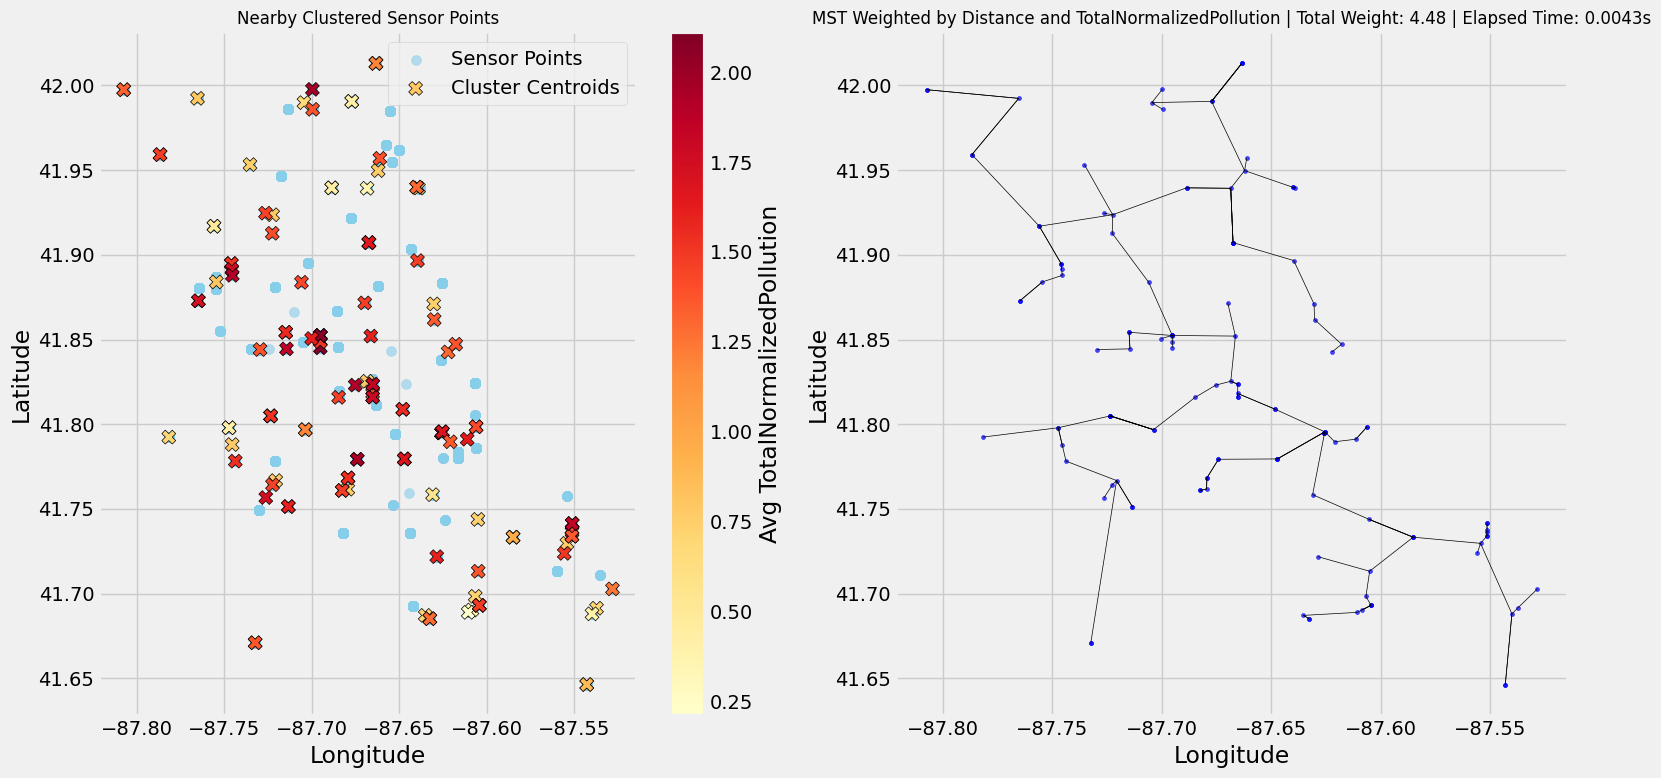

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create a figure with 2 subplots side-by-side for visual comparison

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Cluster the sampled data based on spatial proximity and pollution, and plot the centroids
clustered_sample, centroids_sample = cluster_nearby_points(Sample_Data, Analyzing_Pollution_Column, ax=ax[0])


# Right plot: Visualize the Minimum Spanning Tree based on distance and pollution from cluster centroids
mst_with_pollution(centroids_sample, Analyzing_Pollution_Column, ax=ax[1])
plt.tight_layout()
plt.show()

In [ ]:
'''

In the above plots:

1) Left Plot – Nearby Clustered Sensor Points (Sampled Data):
Even with only 10% of the data, clustering reveals pollution hotspots—highlighted by red centroids—mostly concentrated around central and southern areas. This confirms that spatial pollution patterns remain visible even in smaller datasets.

2) Right Plot – MST on Sampled Cluster Centroids:
The Minimum Spanning Tree efficiently connects high-impact cluster centroids based on pollution-adjusted distances. Though based on a sample, the overall structure resembles the full network, validating the sampling strategy.

'''

'\n\nIn the above plots:\n\n1) Left Plot – Nearby Clustered Sensor Points (Sampled Data):\nEven with only 10% of the data, clustering reveals pollution hotspots—highlighted by red centroids—mostly concentrated around central and southern areas. This confirms that spatial pollution patterns remain visible even in smaller datasets.\n\n2) Right Plot – MST on Sampled Cluster Centroids:\nThe Minimum Spanning Tree efficiently connects high-impact cluster centroids based on pollution-adjusted distances. Though based on a sample, the overall structure resembles the full network, validating the sampling strategy.\n\n'

In [ ]:
#Sample_Data_By_Geohash = group_and_average(Sample_Data, "GeoHashCode")
#Sample_Data_By_Geohash

In [ ]:
#fig, ax = plt.subplots(1, 2, figsize=(16, 8))
#Sample_Data_By_Geohash.plot.scatter(x = "Longitude", y = "Latitude", ax=ax[0], c='skyblue', title="Sensors Distribution")
#mst_with_pollution(Sample_Data, 'CalibratedPM25', ax=ax[1])
#plt.tight_layout()
#plt.show()

<Axes: xlabel='TotalSensors', ylabel='TotalNormalizedPollution'>

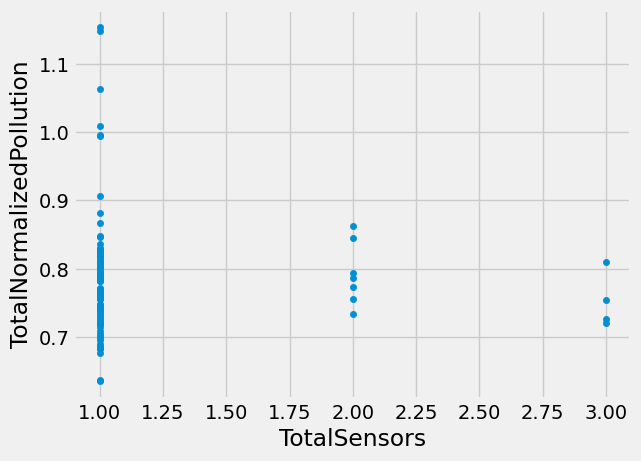

In [ ]:
# Creates a scatter plot to explore the relationship between the number of sensors in a geohash region
# and the average pollution level for that region.
Pollution_By_Geohash.plot.scatter("TotalSensors", Analyzing_Pollution_Column)

In [ ]:
'''
This scatter plot shows that most geohash areas have only one sensor, with varying pollution levels. Areas with two or three sensors tend to have slightly lower pollution on average, suggesting better coverage might help with pollution management—but the difference is not strong.
'''

'\nThis scatter plot shows that most geohash areas have only one sensor, with varying pollution levels. Areas with two or three sensors tend to have slightly lower pollution on average, suggesting better coverage might help with pollution management—but the difference is not strong.\n'

In [ ]:
# Applies sensor adjustment suggestions for each geohash area based on pollution level,
# current sensor count, and total data records available.
Sensors_Suggestion_By_Geohash = suggest_sensor_adjustment(Pollution_By_Geohash, pollution_column=Analyzing_Pollution_Column, sensor_count_col= "TotalSensors", record_count_col= "TotalRecords")

# Filters and displays only the rows where an action is recommended (not "Maintain current sensor count")
Sensors_Suggestion_By_Geohash[Sensors_Suggestion_By_Geohash["Suggestion"] != "Maintain current sensor count"]

,GeoHashCode,TotalRecords,TotalSensors,DeviceId,Latitude,Longitude,CalibratedPM25,CalibratedO3,CalibratedNO2,NormalizedCalibratedPM25,NormalizedCalibratedO3,NormalizedCalibratedNO2,TotalNormalizedPollution,PollutionLevel,Suggestion
3,dp3ts0,56511,3,2012.944506,41.751499,-87.713489,11.057970,33.037811,6.500428,0.041095,0.464604,0.214920,0.720620,0.163797,"Decrease sensors (low pollution, max sensors)"
4,dp3w7v,56735,3,2009.752587,41.912740,-87.722674,10.927356,34.219436,6.198642,0.040559,0.477026,0.208773,0.726357,0.174886,"Decrease sensors (low pollution, max sensors)"
6,dp3t59,78643,3,2049.996516,41.670993,-87.732458,10.884207,32.735490,8.345802,0.040382,0.461426,0.252512,0.754320,0.228932,"Decrease sensors (low pollution, max sensors)"
91,dp3w55,341,3,2199.392962,41.855243,-87.752470,13.306686,23.299853,15.458856,0.050329,0.362240,0.397410,0.809979,0.336508,"Decrease sensors (low pollution, max sensors)"
100,dp3wj3,11,1,2038.000000,41.843392,-87.654582,17.437273,26.234545,29.963636,0.067291,0.393089,0.692883,1.153263,1.000000,Collect more data before adjusting
101,dp3tvt,9,1,2037.000000,41.823716,-87.646346,16.417778,33.063333,26.370000,0.063104,0.464873,0.619678,1.147655,0.989162,Collect more data before adjusting
102,dp3ttd,13,1,2033.000000,41.759507,-87.644385,13.286923,33.016923,19.513846,0.050248,0.464385,0.480013,0.994646,0.693429,Collect more data before adjusting
103,dp3wkb,5,1,2040.000000,41.881471,-87.672189,15.394000,28.116000,24.962000,0.058900,0.412867,0.590996,1.062763,0.825084,Collect more data before adjusting
104,dp3w5c,8,1,2042.000000,41.844200,-87.724800,14.596250,32.378750,19.647500,0.055625,0.457676,0.482736,0.996037,0.696117,Collect more data before adjusting
105,dp3whj,8,1,2043.000000,41.866448,-87.710325,15.196250,32.521250,20.075000,0.058088,0.459174,0.491444,1.008707,0.720606,Collect more data before adjusting


## **Generating Graph for Paper**

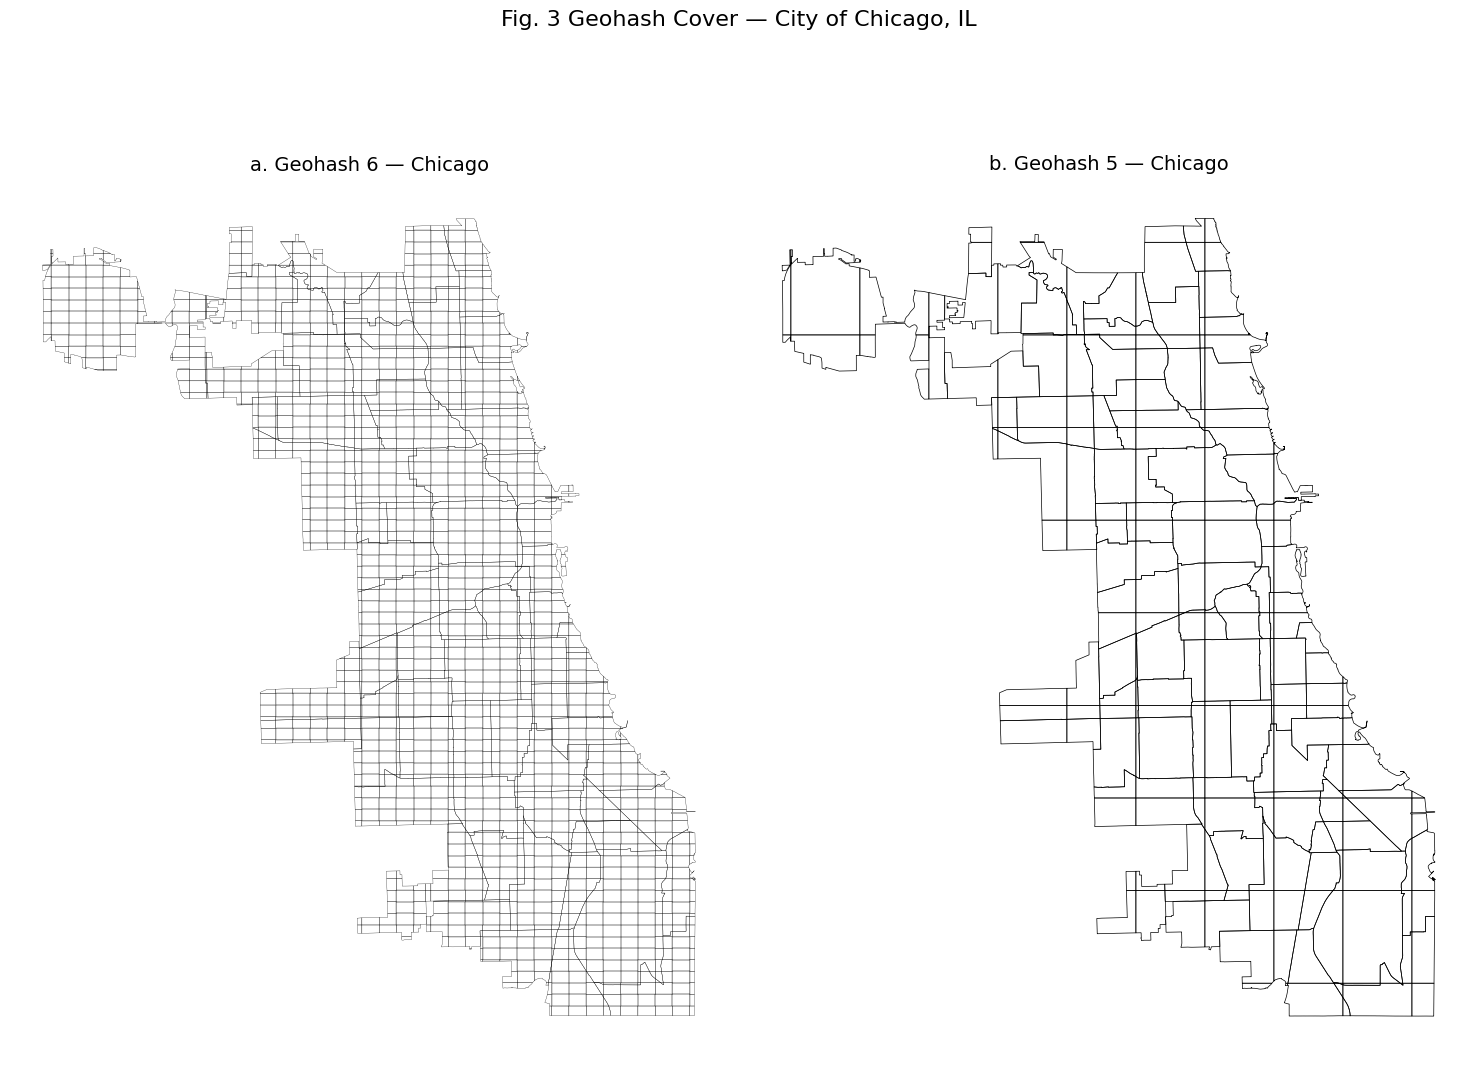

In [ ]:
"""
This script generates and visualizes geohash grids (at precision levels 5 and 6) over the official City of Chicago boundary.

Purpose:
- To understand how different geohash resolutions (precision levels) cover the city area.
- Useful for applications like pollution monitoring, sensor network planning, or spatial data analysis.

What the code does:
1. Loads the official Chicago city boundary from an open GeoJSON API.
2. Defines a bounding box around the city.
3. Generates geohash tiles across that bounding box at specified precision levels (5 and 6).
4. Converts each geohash into a polygon and stores it as a GeoDataFrame.
5. Clips the full grid to match the exact shape of the city (using spatial overlay).
6. Plots the resulting geohash boundaries side-by-side for visual comparison.

The result helps visualize spatial coverage tradeoffs — finer grids (precision 6) offer more detail, while coarser grids (precision 5) offer broader zones.
"""

# Step 1: Load official Chicago city boundary
boundary_url = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
chicago_boundary = gpd.read_file(boundary_url)
chicago_boundary = chicago_boundary.to_crs("EPSG:4326")
# Step 2: Create bounding box around the city shape
bounds = chicago_boundary.total_bounds
lat_min, lon_min, lat_max, lon_max = bounds[1], bounds[0], bounds[3], bounds[2]
# Step 3: Function to create geohash polygons
def generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision):
   step = 0.002 if precision == 6 else 0.01  # adjust depending on precision
   geohash_set = set()
   lats = np.arange(lat_min, lat_max, step)
   lons = np.arange(lon_min, lon_max, step)
   for lat in lats:
       for lon in lons:
           geohash_set.add(gh.encode(lat, lon, precision=precision))
   polygons = []
   for code in geohash_set:
       lat, lon, lat_err, lon_err = gh.decode_exactly(code)
       lat0, lat1 = lat - lat_err, lat + lat_err
       lon0, lon1 = lon - lon_err, lon + lon_err
       poly = Polygon([
           (lon0, lat0), (lon0, lat1), (lon1, lat1), (lon1, lat0)
       ])
       polygons.append({'geohash': code, 'geometry': poly})
   return gpd.GeoDataFrame(polygons, crs="EPSG:4326")
# Step 4: Generate grids
geo_df_6 = generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision=6)
geo_df_5 = generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision=5)
# Step 5: Clip to real city shape
geo_df_6_clipped = gpd.overlay(geo_df_6, chicago_boundary, how='intersection')
geo_df_5_clipped = gpd.overlay(geo_df_5, chicago_boundary, how='intersection')
# Step 6: Plot with white background
fig, axes = plt.subplots(1, 2, figsize=(15, 12), facecolor='none')
# Set each subplot background to white
for ax in axes:
   ax.set_facecolor('none')
geo_df_6_clipped.boundary.plot(ax=axes[0], color='black', linewidth=0.2)
axes[0].set_title("a. Geohash 6 — Chicago", fontsize=14)
axes[0].set_axis_off()
geo_df_5_clipped.boundary.plot(ax=axes[1], color='black', linewidth=0.5)
axes[1].set_title("b. Geohash 5 — Chicago", fontsize=14)
axes[1].set_axis_off()
plt.suptitle("Fig. 2 Geohash Cover — City of Chicago, IL", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

<ipython-input-61-7aee5f513106>:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df['geohash'] = Chicago_df.apply(lambda row: gh.encode(row['Latitude'], row['Longitude'], precision=6), axis=1)


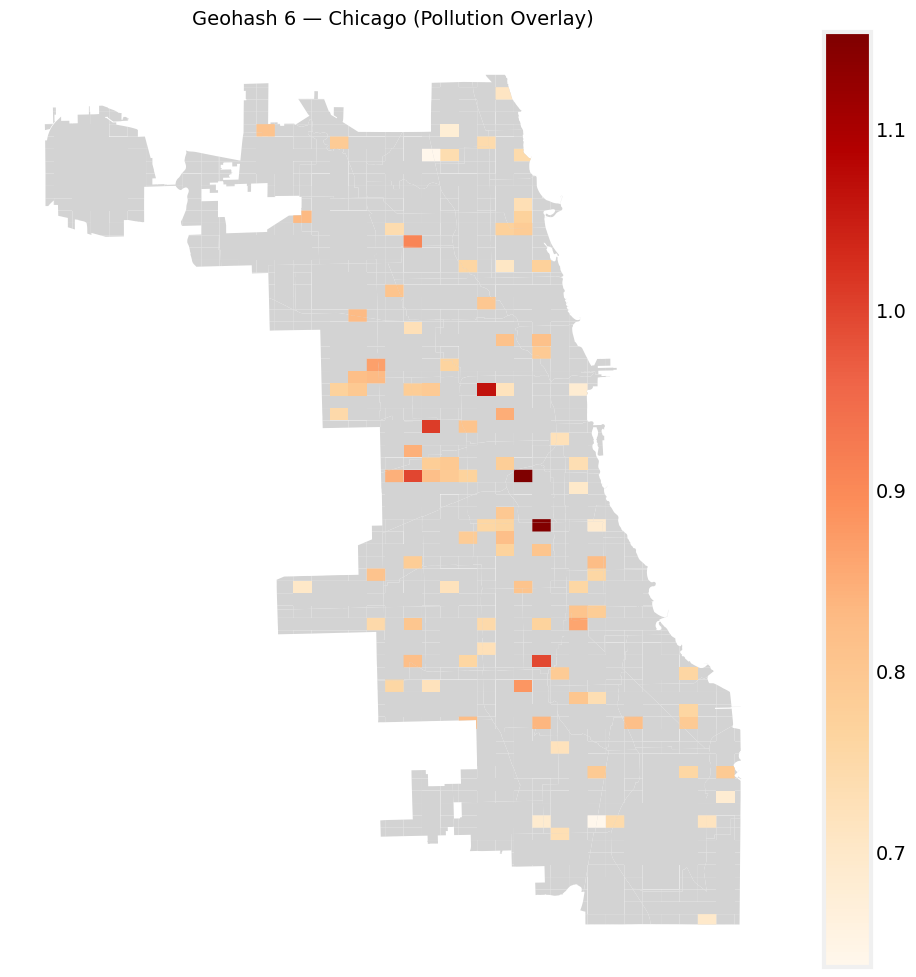

In [ ]:
"""
This script visualizes average pollution levels across Chicago using geohash spatial grids (precision 6).

Purpose:
- To spatially analyze pollution distribution across the city.
- To overlay average pollution data on geohash cells clipped to the official Chicago boundary.

Workflow:
1. Load the official Chicago city boundary from the City of Chicago's open GeoJSON endpoint.
2. Generate a grid of geohash polygons (precision = 6) that span the city.
3. Clip the grid to fit exactly within Chicago’s boundaries.
4. Encode geohash locations for each pollution reading in the dataset (`Chicago_df`).
5. Aggregate average pollution values per geohash and merge with geohash polygons.
6. Plot the full geohash grid in light gray, and overlay color-coded cells where pollution data is available.

Result:
The map highlights which areas of Chicago have higher or lower pollution, based on geohash-level aggregation.
This helps in identifying spatial pollution trends and planning targeted interventions.
"""

# Step 1: Load Chicago city boundary
boundary_url = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
chicago_boundary = gpd.read_file(boundary_url).to_crs("EPSG:4326")
# Step 2: Define bounding box
bounds = chicago_boundary.total_bounds
lat_min, lon_min, lat_max, lon_max = bounds[1], bounds[0], bounds[3], bounds[2]
# Step 3: Generate geohash grid
def generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision):
   step = 0.002 if precision == 6 else 0.01
   geohash_set = set()
   lats = np.arange(lat_min, lat_max, step)
   lons = np.arange(lon_min, lon_max, step)
   for lat in lats:
       for lon in lons:
           geohash_set.add(gh.encode(lat, lon, precision=precision))
   polygons = []
   for code in geohash_set:
       lat, lon, lat_err, lon_err = gh.decode_exactly(code)
       lat0, lat1 = lat - lat_err, lat + lat_err
       lon0, lon1 = lon - lon_err, lon + lon_err
       poly = Polygon([(lon0, lat0), (lon0, lat1), (lon1, lat1), (lon1, lat0)])
       polygons.append({'geohash': code, 'geometry': poly})
   return gpd.GeoDataFrame(polygons, crs="EPSG:4326")
# Step 4: Generate and clip grid
geo6 = generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision=6)
geo6_clipped = gpd.overlay(geo6, chicago_boundary, how='intersection')
# Step 5: Add geohash to your data and merge
Chicago_df['geohash'] = Chicago_df.apply(lambda row: gh.encode(row['Latitude'], row['Longitude'], precision=6), axis=1)
pollution_agg = Chicago_df.groupby('geohash')[Analyzing_Pollution_Column].mean().reset_index()
pollution_gdf = geo6_clipped.merge(pollution_agg, on='geohash', how='left')
# Step 6: Plot
fig, ax = plt.subplots(figsize=(10, 10), facecolor='none')
ax.set_facecolor('none')
# Plot all in gray
geo6_clipped.plot(ax=ax, color='lightgray', linewidth=0)
# Overlay pollution-colored cells
pollution_gdf.dropna(subset=[Analyzing_Pollution_Column]).plot(
   ax=ax, column=Analyzing_Pollution_Column, cmap='OrRd', linewidth=0, legend=True
)
ax.set_title("Geohash 6 — Chicago (Pollution Overlay)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

<ipython-input-62-c90cca63f42b>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Chicago_df['geohash'] = Chicago_df.apply(lambda row: gh.encode(row['Latitude'], row['Longitude'], precision=6), axis=1)
<ipython-input-62-c90cca63f42b>:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  polluted_cells['centroid'] = polluted_cells.geometry.centroid


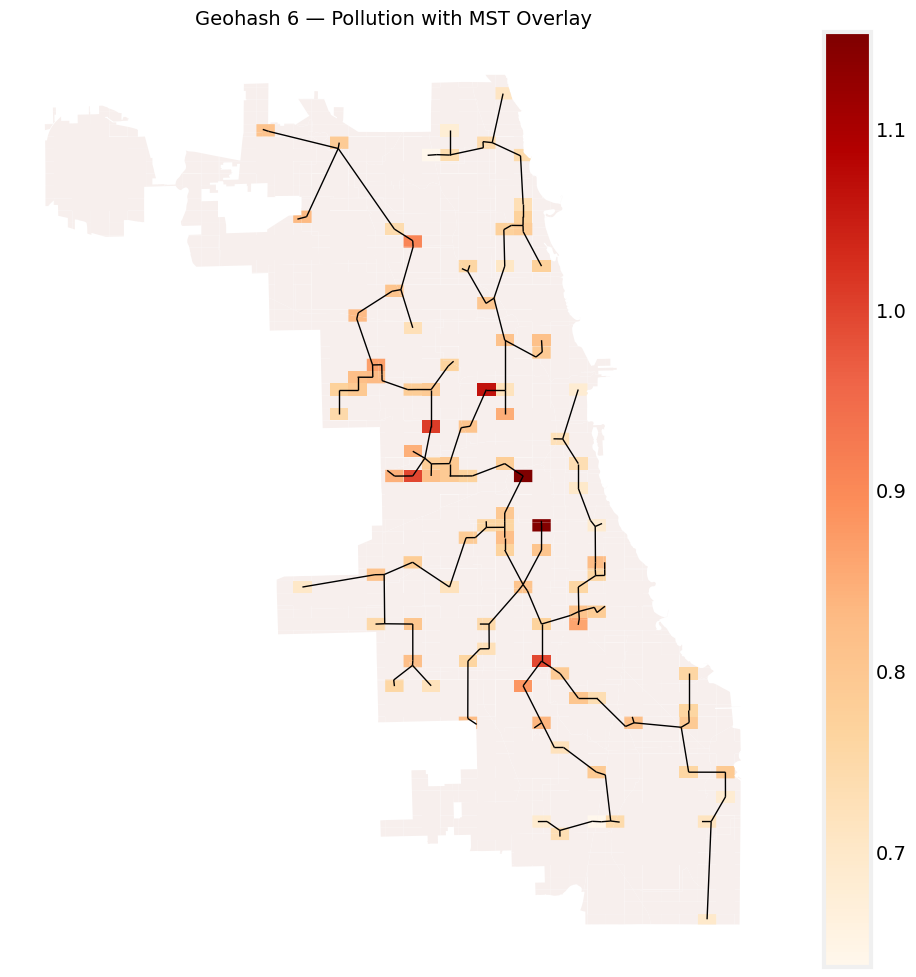

In [ ]:
"""
This script visualizes pollution across Chicago using geohash grids (precision 6) and overlays a Minimum Spanning Tree (MST)
to show the most efficient spatial connection between polluted areas.

Purpose:
- To identify how polluted geohash regions are spatially distributed.
- To compute the shortest path that connects these regions using geographic distances.
- Useful for planning efficient sensor traversal, maintenance routing, or pollution hotspot linking.

Workflow:
1. Load the official Chicago city boundary from a public GeoJSON source.
2. Generate a geohash grid covering the city at precision level 6.
3. Clip the geohash grid to fit exactly within the city boundary.
4. Assign geohash codes to sensor data and calculate average pollution per geohash.
5. Identify centroids of polluted geohash cells (non-null pollution values).
6. Compute a pairwise distance matrix and construct the Minimum Spanning Tree (MST).
7. Visualize:
   - Light gray grid = complete geohash coverage.
   - Red-colored cells = areas with recorded pollution data (higher = darker).
   - Black lines = MST connecting polluted regions.

Result:
A combined spatial and network view of pollution spread and optimal interconnection across the city.
"""

# Step 1: Load Chicago boundary
boundary_url = "https://data.cityofchicago.org/api/geospatial/igwz-8jzy?method=export&format=GeoJSON"
chicago_boundary = gpd.read_file(boundary_url).to_crs("EPSG:4326")
# Step 2: Define bounds
bounds = chicago_boundary.total_bounds
lat_min, lon_min, lat_max, lon_max = bounds[1], bounds[0], bounds[3], bounds[2]
# Step 3: Generate geohash grid
def generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision):
   step = 0.002 if precision == 6 else 0.01
   geohash_set = set()
   lats = np.arange(lat_min, lat_max, step)
   lons = np.arange(lon_min, lon_max, step)
   for lat in lats:
       for lon in lons:
           geohash_set.add(gh.encode(lat, lon, precision=precision))
   polygons = []
   for code in geohash_set:
       lat, lon, lat_err, lon_err = gh.decode_exactly(code)
       lat0, lat1 = lat - lat_err, lat + lat_err
       lon0, lon1 = lon - lon_err, lon + lon_err
       poly = Polygon([(lon0, lat0), (lon0, lat1), (lon1, lat1), (lon1, lat0)])
       polygons.append({'geohash': code, 'geometry': poly})
   return gpd.GeoDataFrame(polygons, crs="EPSG:4326")
# Step 4: Create and clip grid
geo6 = generate_geohash_grid(lat_min, lat_max, lon_min, lon_max, precision=6)
geo6_clipped = gpd.overlay(geo6, chicago_boundary, how='intersection')
# Step 5: Assign geohashes to data and calculate mean pollution
Chicago_df['geohash'] = Chicago_df.apply(lambda row: gh.encode(row['Latitude'], row['Longitude'], precision=6), axis=1)
pollution_agg = Chicago_df.groupby('geohash')[Analyzing_Pollution_Column].mean().reset_index()
pollution_gdf = geo6_clipped.merge(pollution_agg, on='geohash', how='left')
# Step 6: Compute centroids of pollution geohashes
polluted_cells = pollution_gdf.dropna(subset=[Analyzing_Pollution_Column]).copy()
polluted_cells['centroid'] = polluted_cells.geometry.centroid
centroids = np.array([[pt.x, pt.y] for pt in polluted_cells['centroid']])
# Step 7: Build MST
dist_matrix = distance_matrix(centroids, centroids)
mst_sparse = minimum_spanning_tree(dist_matrix)
mst_coo = mst_sparse.tocoo()
# Step 8: Plot map with MST
fig, ax = plt.subplots(figsize=(10, 10), facecolor='none')
ax.set_facecolor('none')
# Plot all in gray
geo6_clipped.plot(ax=ax, color='#F7EFED', linewidth=0)
# Plot pollution-colored cells
polluted_cells.plot(ax=ax, column=Analyzing_Pollution_Column, cmap='OrRd', linewidth=0, legend=True)
# Plot MST lines
for i, j, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
   x0, y0 = centroids[i]
   x1, y1 = centroids[j]
   ax.plot([x0, x1], [y0, y1], color='black', linewidth=1)
ax.set_title("Geohash 6 — Pollution with MST Overlay", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()